##### Decision Tree to predict Titanic survival (Alive or Dead) 

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [8]:
# Load the dataset
titanic = pd.read_csv('../data/titanic.csv')
print(titanic.columns)
titanic.head(5)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
titanic = titanic[['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Survived']]
titanic = titanic.dropna() # Drop rows with missing values
titanic.head(5)

,Pclass,Sex,Age,Fare,SibSp,Parch,Survived
0,3,male,22.0,7.2500,1,0,0
1,1,female,38.0,71.2833,1,0,1
2,3,female,26.0,7.9250,0,0,1
3,1,female,35.0,53.1000,1,0,1
4,3,male,35.0,8.0500,0,0,0


### Encode categorical data: LabelEncoder()

In [ ]:
le = LabelEncoder()
titanic['Sex'] = le.fit_transform(titanic['Sex'])

#### Split Data into Features and Target

In [25]:
x = titanic.drop('Survived', axis = 1)
y = titanic['Survived']

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Train Decision Tree Classifier

In [53]:
model = DecisionTreeClassifier(
    criterion='entropy',  # Use 'gini' for Gini impurity or 'entropy' for information gain
    max_depth=5,          # Limit the depth of the tree to prevent overfitting
    random_state=42       # For reproducibility
)

model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### predict the model

In [54]:
y_pred = model.predict(x_test)  # Predict the survival of passengers in the test data set
print("Predictions:", y_pred)

Predictions: [0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0
 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0
 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0 0 1 1]


#### Evaluate the model

In [55]:
# Evaluate the model's accuracy on the test set
print("Accuracy:", model.score(x_test, y_test))

Accuracy: 0.7412587412587412


In [56]:
# Check accuracy

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree model: {accuracy:.2f}")

print(classification_report(y_test, y_pred, target_names=['Dead', 'Alive']))

Accuracy of the Decision Tree model: 0.74
              precision    recall  f1-score   support

        Dead       0.78      0.79      0.79        87
       Alive       0.67      0.66      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



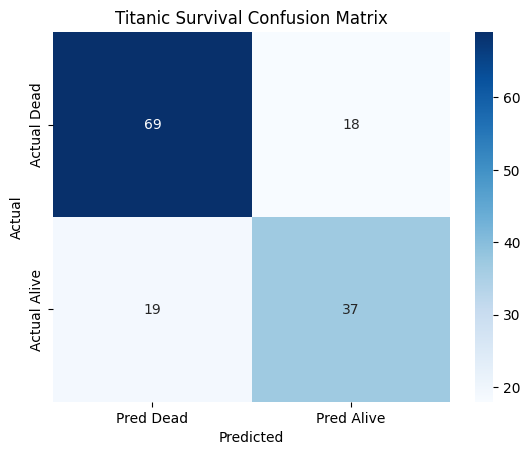

In [44]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Dead', 'Pred Alive'],
            yticklabels=['Actual Dead', 'Actual Alive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Titanic Survival Confusion Matrix')
plt.show()

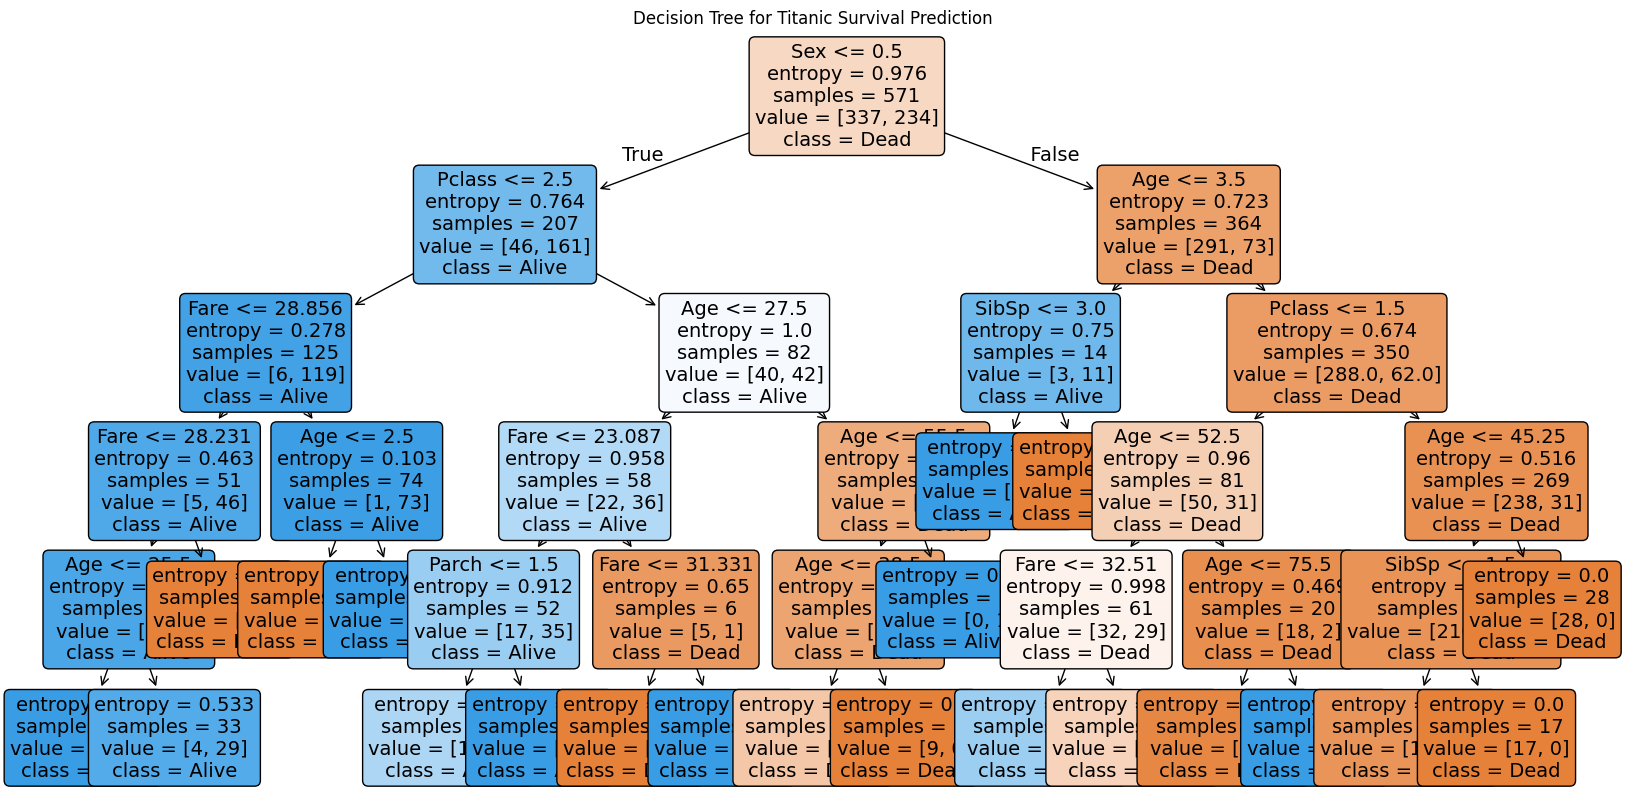

In [48]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['Dead', 'Alive'],
    filled=True,
    rounded=True,
    fontsize=14
)
plt.title('Decision Tree for Titanic Survival Prediction')
plt.show()
